In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

For both tasks in the assignment a) labelling to the broadest category, b) labelling to the most specific category possible for a particular article we need to understand the distribution of the data that we have in our training corpus. 

Since the dataset is very large and computationally intensive to work with, and important part of the assignment is to make a manageable dataset that we are able to work with, and quickly iterate upon our models. This dataset should be small to enable fast iterations, yet representative of the problem's distribution. 

In essesnce we would prefer if we had a dataset of maybe 5000 articles that is as representative as possible. 

For the first task (broadest H1 labels), we build a 5,000-article subset from **`news.csv` ∪ `news_test.csv`** (same `articles` table as above) by **stratifying on the joint H1 pattern** (which of CCAT, ECAT, GCAT, MCAT appear). That preserves the same **multi-label** top-level rates as that full pool—not a naive 1,250-per-label split, which would ignore overlap between tags. 

For the second task (fine-grained / hierarchical labels), we build a **leaf-balanced** subset from the same **full** article pool: keep only deepest-level categories with at least **60** articles (so each leaf can support a train/test split), then take up to **200** articles per such leaf and **union** the ids (duplicates across leaves collapse to one row per article). Leaves below the 60-article floor are excluded. 

We need to first of all visualize the distirbution of the training data included in news and news_test with topics in news_topics. 

This data engineering will inform the rest of this assignment in particular the creation of a solid, smaller data set we can utilize to benchmark our model and it's performance throughout iterations of the data.

**Label sidecars (CSV alongside articles):**  
- Stratified 5k: `labels_5k_stratified_h1.csv` — `id` plus binary columns `CCAT`, `ECAT`, `GCAT`, `MCAT`.  
- Leaf pool: `labels_leaf_min60_cap200_long.csv` — long format (`id`, `cat`, `level`); and `labels_leaf_min60_cap200_by_article.csv` — one row per `id` with `labels_hierarchy` (`h1:CCAT;h2:…` sorted by level). 





In [3]:
# Load & concat articles
articles = pd.concat([pd.read_csv("../news.csv"), pd.read_csv("../news_test.csv")], ignore_index=True)
labels = pd.read_csv("../news_topics.csv")
labels["cat"] = labels["cat"].str.strip()
# Restrict to rows that belong to articles we actually have (news + news_test)
labels = labels[labels["id"].isin(articles["id"])]

# Build category → hierarchy level lookup from h1-h5 (only read label column)
cat_to_level = {}
for level in ["h1", "h2", "h3", "h4", "h5"]:
    h = pd.read_csv(f"../{level}.csv", usecols=[0])
    for cat in h.iloc[:, 0].str.strip():
        cat_to_level[cat] = level
cat_to_level["C1511"] = "h5"  # only h5 category, missing from h5.csv

# Tag each label row with its level
labels["level"] = labels["cat"].map(cat_to_level)

print(f"Total articles:       {len(articles):,}")
print(f"Total label rows:     {len(labels):,}")
print(f"Unique categories:    {labels['cat'].nunique()}")
print(f"\nCategories per level:")
print(labels.drop_duplicates("cat").groupby("level").size().sort_index().to_string())

Total articles:       413,765
Total label rows:     1,340,410
Unique categories:    103

Categories per level:
level
h1     4
h2    22
h3    33
h4    43
h5     1


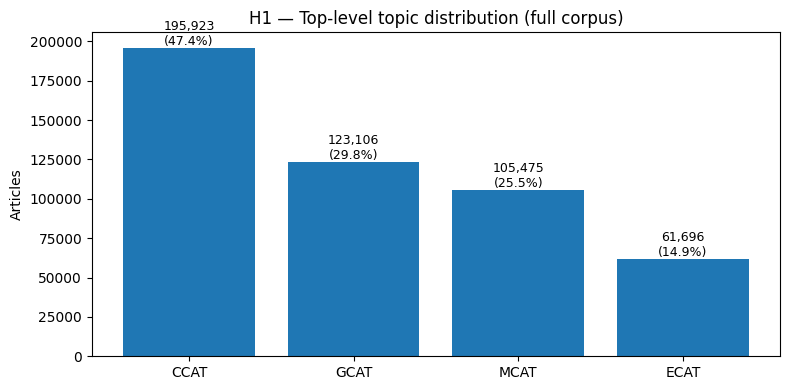

In [4]:
# H1 distribution
h1_labels = labels[labels["level"] == "h1"]
h1_counts = h1_labels.groupby("cat")["id"].nunique().sort_values(ascending=False)
total = len(articles)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(h1_counts.index, h1_counts.values)
for bar, v in zip(bars, h1_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + total*0.005,
            f"{v:,}\n({v/total*100:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("Articles")
ax.set_title("H1 — Top-level topic distribution (full corpus)")
plt.tight_layout()
plt.show()

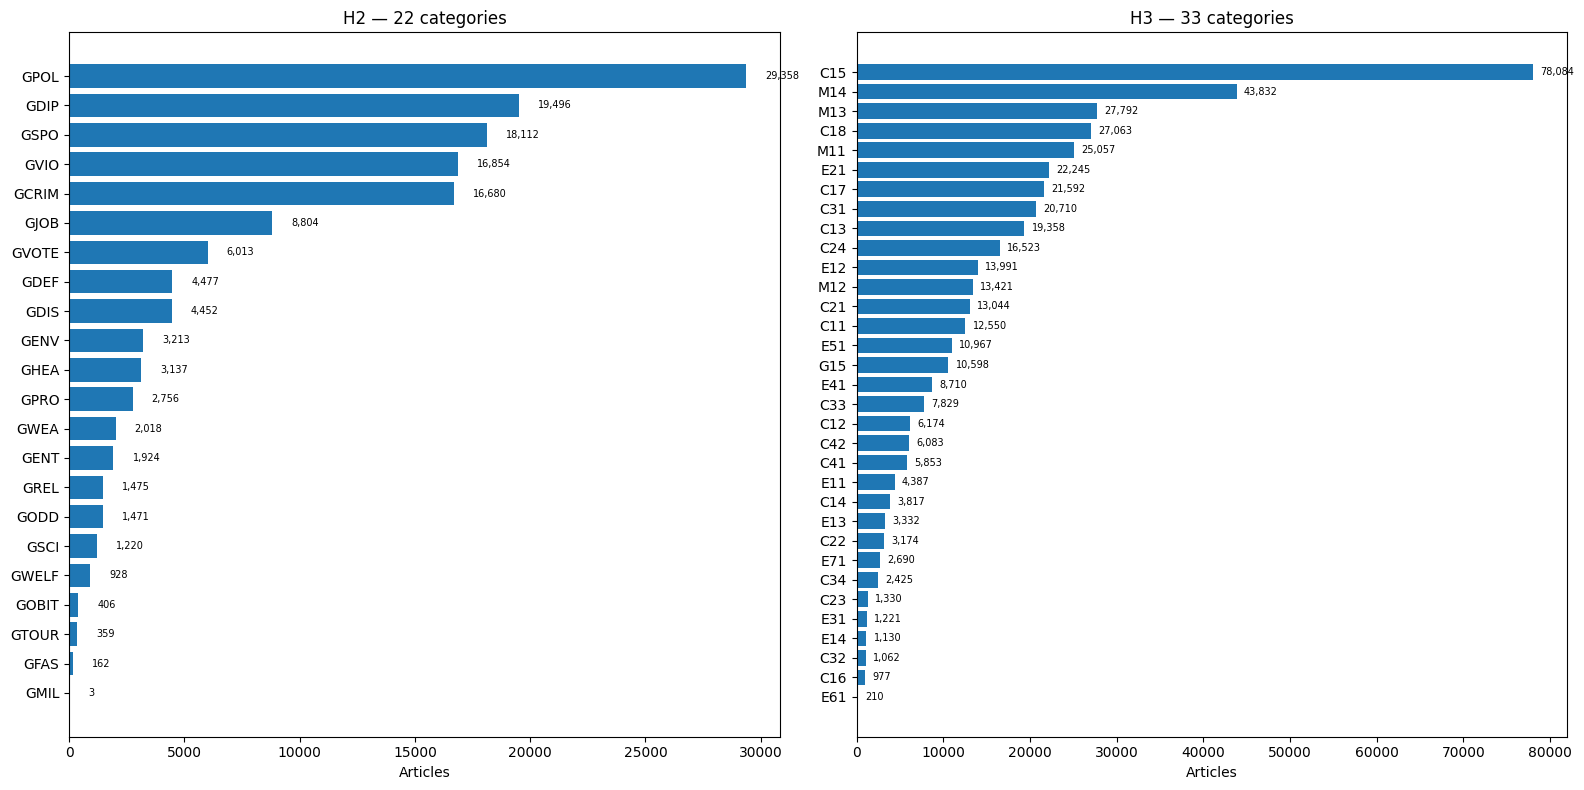

In [5]:
# H2 and H3 distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, lvl in zip(axes, ["h2", "h3"]):
    sub = labels[labels["level"] == lvl]
    counts = sub.groupby("cat")["id"].nunique().sort_values(ascending=True)
    ax.barh(counts.index, counts.values)
    for i, (cat, v) in enumerate(counts.items()):
        ax.text(v + total*0.002, i, f"{v:,}", va="center", fontsize=7)
    ax.set_xlabel("Articles")
    ax.set_title(f"{lvl.upper()} — {len(counts)} categories")

plt.tight_layout()
plt.show()

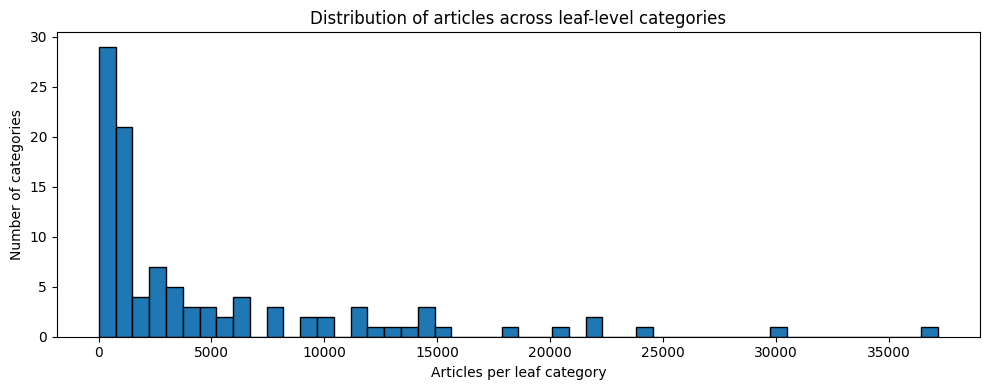

Unique leaf categories: 102
Median articles/cat:    1522
Min:                    15
Max:                    37,161
Categories with < 50 articles: 5


In [6]:
# Leaf-level coverage analysis
# For each article, find its deepest (most specific) category assignments
level_rank = {"h5": 5, "h4": 4, "h3": 3, "h2": 2, "h1": 1}
labels["rank"] = labels["level"].map(level_rank)

# Per-article max depth
art_max = labels.groupby("id")["rank"].max().reset_index()
art_max.columns = ["id", "max_rank"]
leaf = labels.merge(art_max, on="id")
leaf = leaf[leaf["rank"] == leaf["max_rank"]]

leaf_counts = leaf.groupby("cat")["id"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(leaf_counts.values, bins=50, edgecolor="black")
ax.set_xlabel("Articles per leaf category")
ax.set_ylabel("Number of categories")
ax.set_title("Distribution of articles across leaf-level categories")
plt.tight_layout()
plt.show()

print(f"Unique leaf categories: {len(leaf_counts)}")
print(f"Median articles/cat:    {leaf_counts.median():.0f}")
print(f"Min:                    {leaf_counts.min()}")
print(f"Max:                    {leaf_counts.max():,}")
print(f"Categories with < 50 articles: {(leaf_counts <  50).sum()}")

In [12]:
# --- Deepest label vs taxonomy leaf (topics.csv) ---
# For each article, take all category rows at that article's maximum depth (h1–h5).
# In the RCV1 tree, a leaf is a node with no children. If every deepest label is an
# *internal* node, the article never received a leaf-level tag—it stops at a parent.

import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from topic_hierarchy import load_topic_tree

if "rank" not in labels.columns:
    level_rank = {"h5": 5, "h4": 4, "h3": 3, "h2": 2, "h1": 1}
    labels["rank"] = labels["level"].map(level_rank)

lab = labels.dropna(subset=["rank"]).copy()
art_max = lab.groupby("id")["rank"].max().reset_index()
art_max.columns = ["id", "max_rank"]
deepest_rows = lab.merge(art_max, on="id")
deepest_rows = deepest_rows[deepest_rows["rank"] == deepest_rows["max_rank"]]

tree = load_topic_tree("../topics.csv")
tax_leaves = tree.leaf_nodes()
all_nodes = tree.all_nodes()


def deepest_vs_leaf(cat_set: set) -> str:
    """Return whether any deepest category is a taxonomy leaf."""
    in_tree = [c for c in cat_set if c in all_nodes]
    if not in_tree:
        return "not_in_tree"
    if any(c in tax_leaves for c in cat_set if c in all_nodes):
        return "has_leaf"
    return "parent_only"


by_article = {}
for aid, grp in deepest_rows.groupby("id"):
    by_article[aid] = deepest_vs_leaf(set(grp["cat"].dropna()))

counts = Counter(by_article.values())
n_art = len(by_article)
n_parent_only = counts["parent_only"]
n_has_leaf = counts["has_leaf"]
n_missing = counts.get("not_in_tree", 0)

print("Deepest human label vs taxonomy leaf (topics.csv)")
print(f"  Articles with ≥1 deepest label on a taxonomy leaf:        {n_has_leaf:,} ({100 * n_has_leaf / n_art:.2f}%)")
print(f"  Articles whose deepest labels are all non-leaf (parent): {n_parent_only:,} ({100 * n_parent_only / n_art:.2f}%)")
if n_missing:
    print(f"  Deepest categories missing from tree:                    {n_missing:,}")

# Which internal nodes appear most often as the "deepest" stop?
parent_ids = [i for i, s in by_article.items() if s == "parent_only"]
top_parent_cats = (
    deepest_rows[deepest_rows["id"].isin(parent_ids)]
    .drop_duplicates(["id", "cat"])
    .groupby("cat")["id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)
print("\nTop 15 non-leaf categories that are the deepest label for some article (count of articles):")
print(top_parent_cats.to_string())

# Simple sanity check: every article should be classifiable
assert n_art == len(articles), "expected one status per article"
assert n_missing == 0, "unexpected: some deepest cats not in topics.csv"
print("\n(checks passed: full coverage, all deepest cats in tree)")

KeyboardInterrupt: 

In [8]:
# Summary stats table
rows = []
for lvl in ["h1", "h2", "h3", "h4", "h5"]:
    sub = labels[labels["level"] == lvl]
    counts = sub.groupby("cat")["id"].nunique()
    rows.append({
        "Level": lvl,
        "Categories": len(counts),
        "Mean articles": int(counts.mean()),
        "Median articles": int(counts.median()),
        "Min articles": counts.min(),
        "Max articles": counts.max(),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

Level  Categories  Mean articles  Median articles  Min articles  Max articles
   h1           4         121550           114290         61696        195923
   h2          22           6514             2946             3         29358
   h3          33          13249             8710           210         78084
   h4          43           6090             2219            17         42214
   h5           1          11754            11754         11754         11754


Stratified sample: n = 5000 (target 5000)

H1 presence rate — share of articles that carry each top-level tag:
         pool (news∪test)    5k sample   Δ (pp)
  CCAT:             47.35%       47.36%    +0.009
  ECAT:             14.91%       14.90%    -0.011
  GCAT:             29.75%       29.76%    +0.007
  MCAT:             25.49%       25.50%    +0.008

Saved: ../articles_5k_stratified.csv
Saved: ../labels_5k_stratified_h1.csv  (columns: id + CCAT, ECAT, GCAT, MCAT)


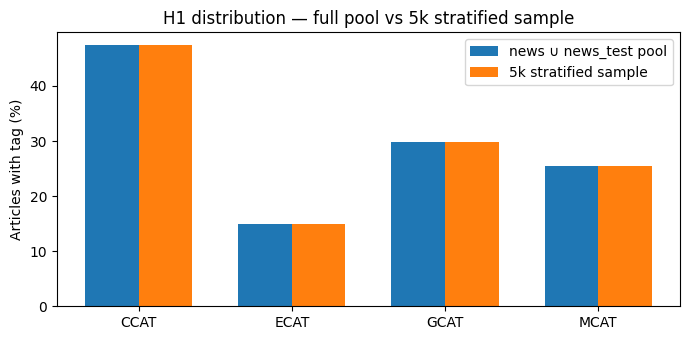

In [9]:
# --- 5,000-article set: match H1 (top-level) distribution of news ∪ news_test ---
# Pool is the same `articles` as cell 2. Each article has a 4-bit pattern over
# (CCAT, ECAT, GCAT, MCAT). Stratifying by this joint pattern preserves multi-label H1 rates.

SAMPLE_N = 5_000
RNG_SEED = 42
h1_order = ["CCAT", "ECAT", "GCAT", "MCAT"]

pool_ids = set(articles["id"])
labels_pool = labels[labels["id"].isin(pool_ids)].copy()
h1_rows = labels_pool.loc[labels_pool["level"] == "h1", ["id", "cat"]].drop_duplicates()
h1_wide = pd.crosstab(h1_rows["id"], h1_rows["cat"]).reindex(columns=h1_order, fill_value=0) > 0

N_pool = len(h1_wide)
assert N_pool == len(pool_ids) and N_pool >= SAMPLE_N

arr = h1_wide[h1_order].values.astype(np.uint8)
packed = (arr[:, 0] << 3) | (arr[:, 1] << 2) | (arr[:, 2] << 1) | arr[:, 3]
packed = pd.Series(packed, index=h1_wide.index)
pat_counts = packed.value_counts()

rng = np.random.default_rng(RNG_SEED)
alloc = (SAMPLE_N * pat_counts / N_pool).round().astype(int)
gap = SAMPLE_N - int(alloc.sum())
order = alloc.sort_values(ascending=False).index.tolist()
step = 1 if gap > 0 else -1
for i in range(abs(gap)):
    alloc.loc[order[i % len(order)]] += step

sampled_ids = []
for p, k in alloc.items():
    if k <= 0:
        continue
    pool = packed[packed == p].index.to_numpy()
    take = rng.choice(pool, size=int(k), replace=False)
    sampled_ids.extend(take.tolist())

articles_5k = (
    articles.set_index("id")
    .loc[sampled_ids]
    .reset_index()
)


def h1_presence_rates(h1_df):
    return {c: float(h1_df[c].mean()) for c in h1_order}


ref_rates = h1_presence_rates(h1_wide)
sub_rates = h1_presence_rates(h1_wide.loc[sampled_ids])

print(f"Stratified sample: n = {len(sampled_ids)} (target {SAMPLE_N})")
print("\nH1 presence rate — share of articles that carry each top-level tag:")
print(f"{'':6} {'pool (news∪test)':>18} {'5k sample':>12}   Δ (pp)")
for c in h1_order:
    r, g = ref_rates[c], sub_rates[c]
    print(f"  {c}:  {r*100:16.2f}%  {g*100:10.2f}%   {(g - r)*100:+7.3f}")

OUT_PATH = "../articles_5k_stratified.csv"
articles_5k.to_csv(OUT_PATH, index=False)
print(f"\nSaved: {OUT_PATH}")

# H1 multi-label targets (four top-level columns, 0/1) — same row order as articles_5k
labels_5k_h1 = h1_wide.loc[sampled_ids, h1_order].astype(np.int8).reset_index()
OUT_LAB = "../labels_5k_stratified_h1.csv"
labels_5k_h1.to_csv(OUT_LAB, index=False)
print(f"Saved: {OUT_LAB}  (columns: id + {', '.join(h1_order)})")

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(h1_order))
w = 0.35
ax.bar(x - w / 2, [ref_rates[c] * 100 for c in h1_order], width=w, label="news ∪ news_test pool")
ax.bar(x + w / 2, [sub_rates[c] * 100 for c in h1_order], width=w, label="5k stratified sample")
ax.set_xticks(x)
ax.set_xticklabels(h1_order)
ax.set_ylabel("Articles with tag (%)")
ax.set_title("H1 distribution — full pool vs 5k stratified sample")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# --- Hierarchy / leaf-level benchmark subset (news ∪ news_test, same `articles` as cell 2) ---
# Require each leaf to have at least MIN_PER_LEAF articles (enough for train+test).
# Drop rarer leaves. For each remaining leaf, take up to CAP_PER_LEAF articles at random.
# Union across leaves → unique article ids (multi-label articles count once).

MIN_PER_LEAF = 60
CAP_PER_LEAF = 200
RNG_SEED = 43

pool_ids = set(articles["id"])
labels_leaf = labels[labels["id"].isin(pool_ids)].copy()

level_rank = {"h5": 5, "h4": 4, "h3": 3, "h2": 2, "h1": 1}
labels_leaf["rank"] = labels_leaf["level"].map(level_rank)
art_max = labels_leaf.groupby("id")["rank"].max().reset_index()
art_max.columns = ["id", "max_rank"]
leaf_rows = labels_leaf.merge(art_max, on="id")
leaf_rows = leaf_rows[leaf_rows["rank"] == leaf_rows["max_rank"]]

leaf_counts = leaf_rows.groupby("cat")["id"].nunique()
eligible = leaf_counts[leaf_counts >= MIN_PER_LEAF].index.sort_values()
dropped = leaf_counts[leaf_counts < MIN_PER_LEAF]

rng = np.random.default_rng(RNG_SEED)
leaf_sampled_ids_set = set()

for cat in eligible:
    pool = leaf_rows.loc[leaf_rows["cat"] == cat, "id"].unique()
    k = min(len(pool), CAP_PER_LEAF)
    leaf_sampled_ids_set.update(rng.choice(pool, size=k, replace=False))

leaf_sampled_ids = sorted(leaf_sampled_ids_set)
articles_leaf_pool = (
    articles.set_index("id")
    .loc[leaf_sampled_ids]
    .reset_index()
)

ids_arr = np.array(leaf_sampled_ids, dtype=np.int64)
rng.shuffle(ids_arr)
split_idx = int(0.8 * len(ids_arr))
train_leaf_ids = sorted(ids_arr[:split_idx].tolist())
test_leaf_ids = sorted(ids_arr[split_idx:].tolist())

print(f"Deepest-label (leaf) categories in full pool (news ∪ news_test): {len(leaf_counts)}")
print(f"Leaves dropped (n < {MIN_PER_LEAF}): {len(dropped)}")
print(f"Leaves kept: {len(eligible)}")
print(f"Unique articles after union (cap {CAP_PER_LEAF}/leaf): {len(leaf_sampled_ids):,}")
print(f"Random 80/20 train/test split on ids: {len(train_leaf_ids):,} / {len(test_leaf_ids):,}")

OUT_ART = "../articles_leaf_min60_cap200.csv"
OUT_TR = "../articles_leaf_min60_cap200_train_ids.csv"
OUT_TE = "../articles_leaf_min60_cap200_test_ids.csv"
articles_leaf_pool.to_csv(OUT_ART, index=False)
pd.Series(train_leaf_ids, name="id").to_csv(OUT_TR, index=False)
pd.Series(test_leaf_ids, name="id").to_csv(OUT_TE, index=False)
print(f"Saved: {OUT_ART}, {OUT_TR}, {OUT_TE}")

# Full hierarchical labels from news_topics (all levels h1–h5) for articles in this pool
leaf_id_set = set(leaf_sampled_ids)
lab_long = (
    labels[labels["id"].isin(leaf_id_set)][["id", "cat", "level"]]
    .drop_duplicates()
    .sort_values(["id", "level", "cat"])
)
OUT_LONG = "../labels_leaf_min60_cap200_long.csv"
lab_long.to_csv(OUT_LONG, index=False)
print(f"Saved: {OUT_LONG}  (one row per id, cat, level)")

lvl_order = {"h1": 1, "h2": 2, "h3": 3, "h4": 4, "h5": 5}


def _pack_hierarchy(g):
    g = g.assign(_o=g["level"].map(lvl_order)).sort_values(["_o", "cat"])
    return ";".join(g["level"] + ":" + g["cat"])


lab_by_article = (
    lab_long.groupby("id", sort=False)
    .apply(_pack_hierarchy)
    .reset_index(name="labels_hierarchy")
)
OUT_PACK = "../labels_leaf_min60_cap200_by_article.csv"
lab_by_article.to_csv(OUT_PACK, index=False)
print(f"Saved: {OUT_PACK}  (one row per id, semicolon-separated level:cat)")

Deepest-label (leaf) categories in full pool (news ∪ news_test): 102
Leaves dropped (n < 60): 7
Leaves kept: 95
Unique articles after union (cap 200/leaf): 18,082
Random 80/20 train/test split on ids: 14,465 / 3,617
Saved: ../articles_leaf_min60_cap200.csv, ../articles_leaf_min60_cap200_train_ids.csv, ../articles_leaf_min60_cap200_test_ids.csv
Saved: ../labels_leaf_min60_cap200_long.csv  (one row per id, cat, level)
Saved: ../labels_leaf_min60_cap200_by_article.csv  (one row per id, semicolon-separated level:cat)


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_66760/1783513465.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_pack_hierarchy)


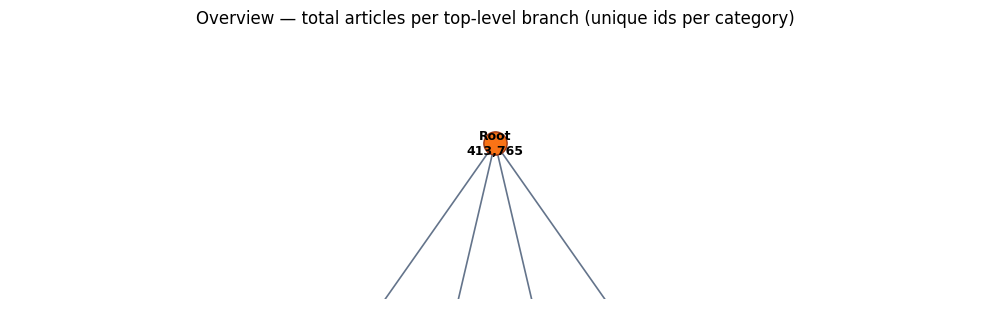

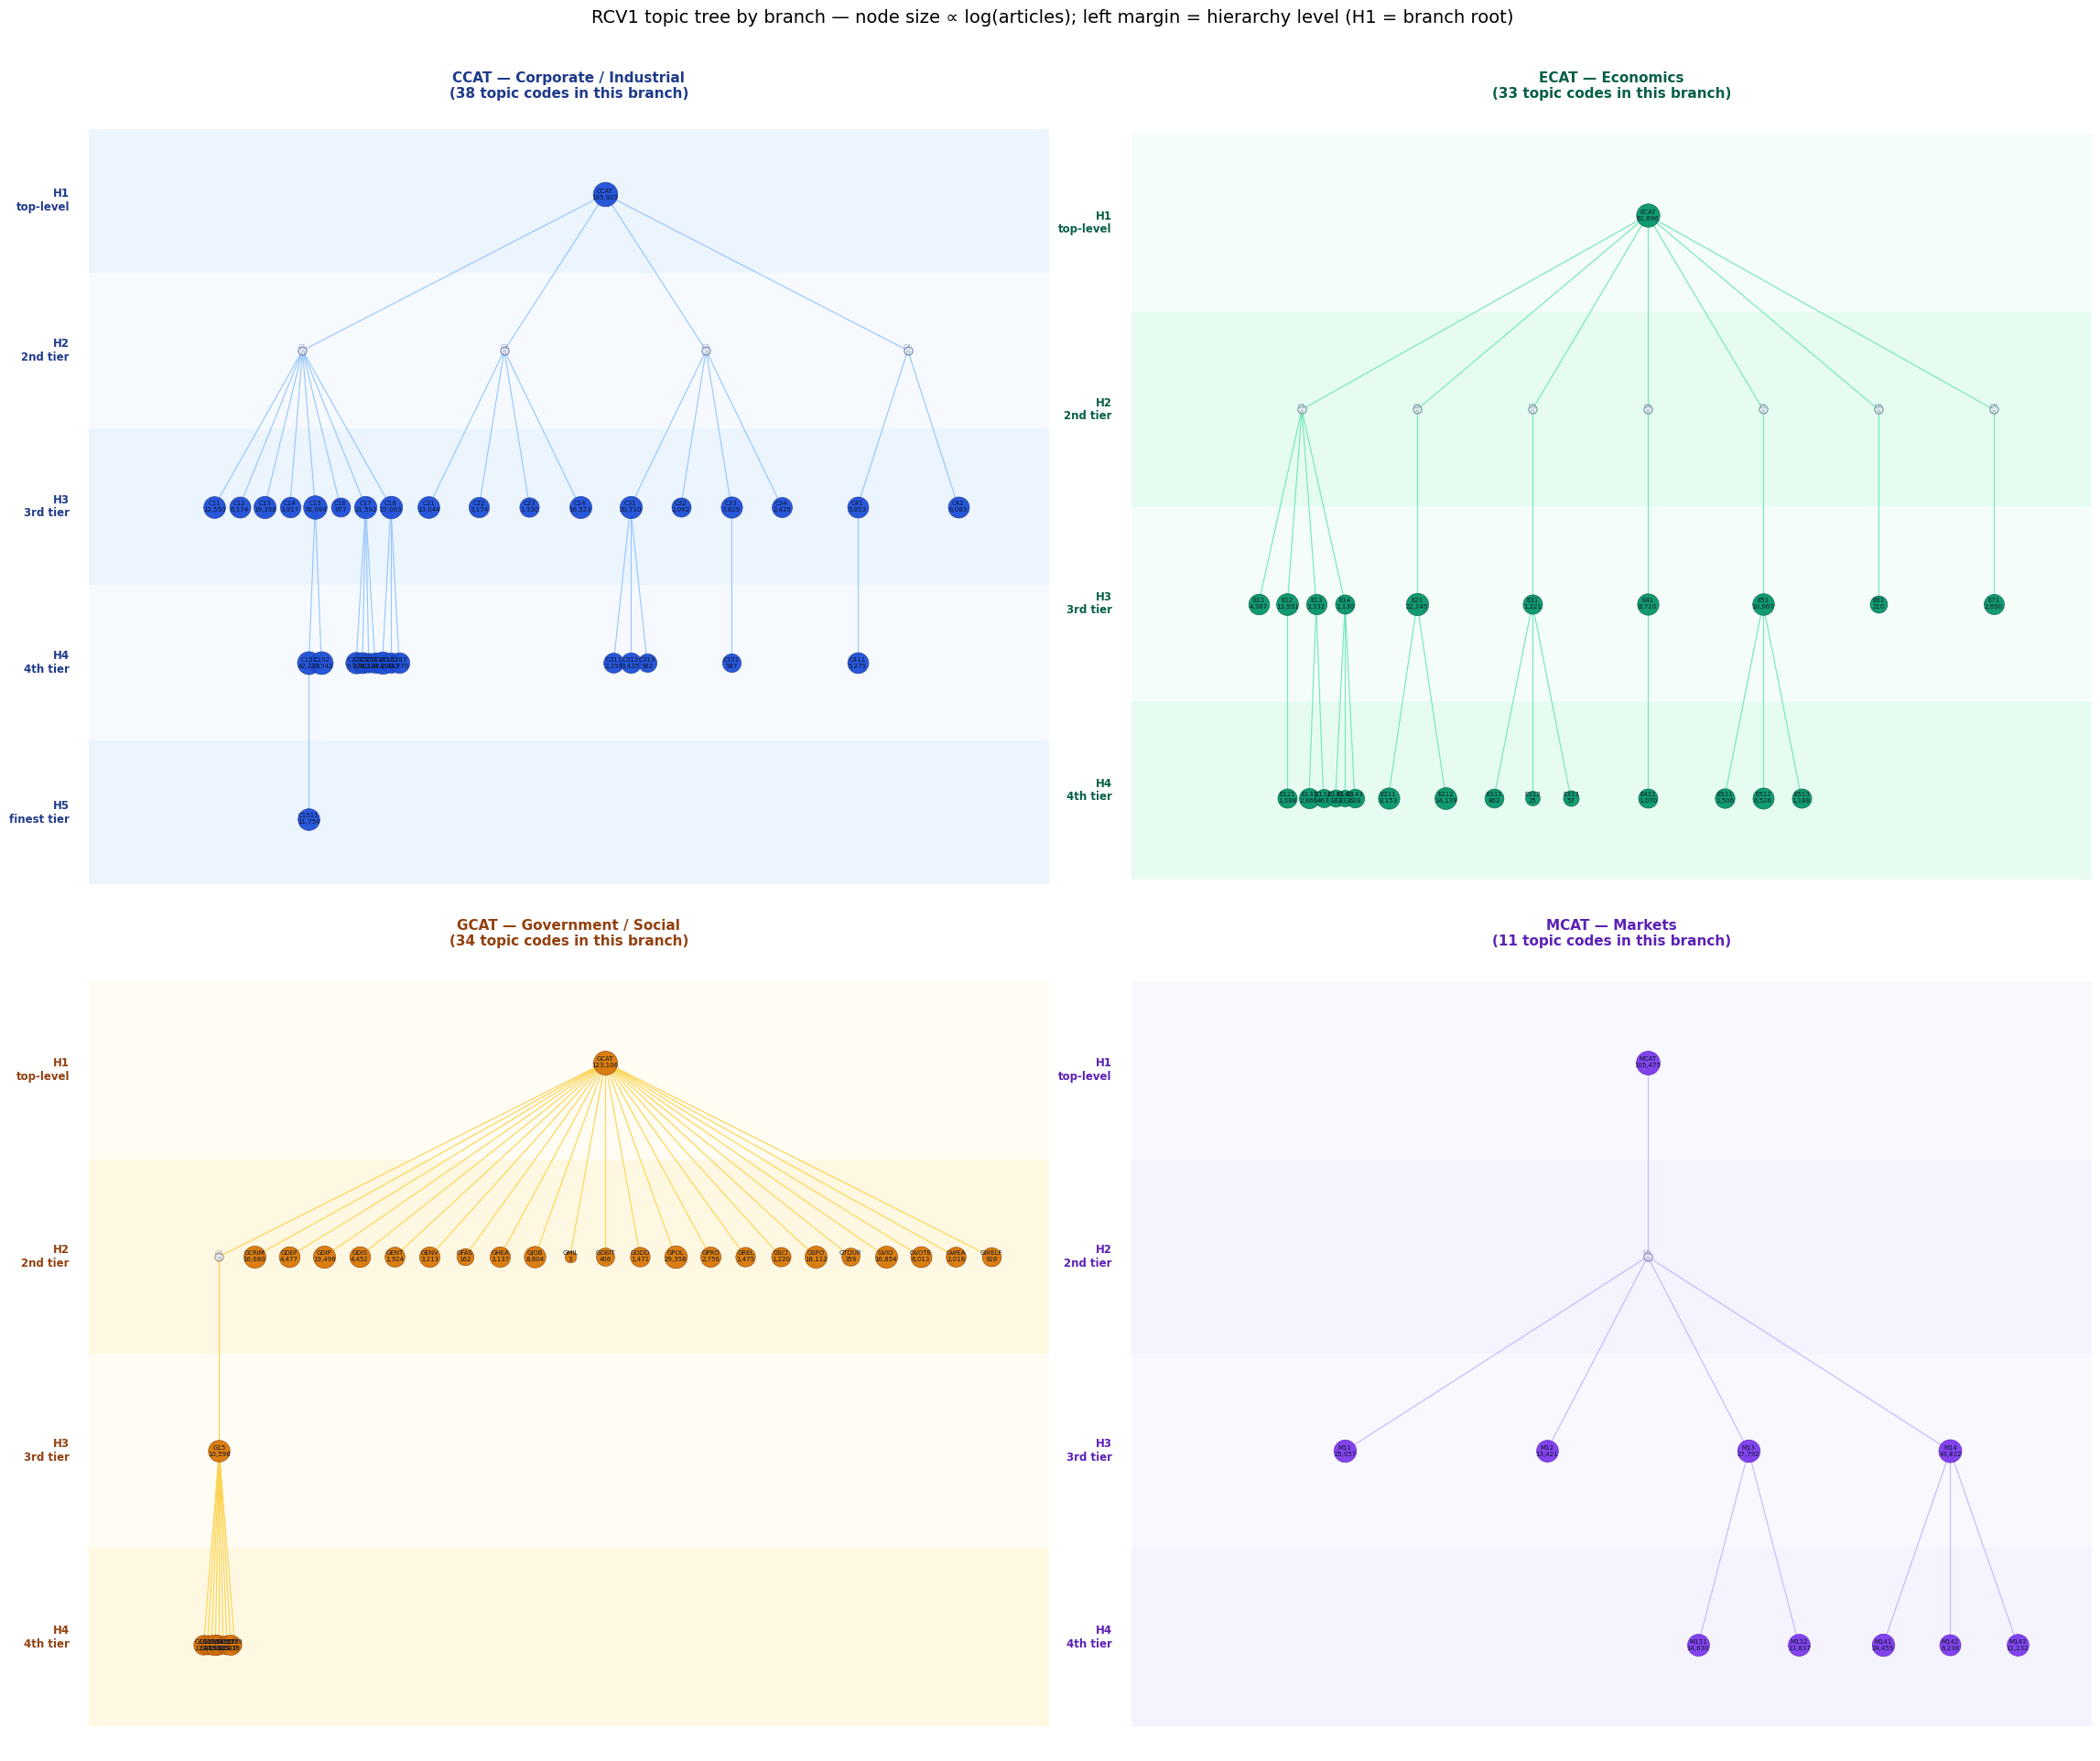

Top 15 categories by article count:
cat
CCAT    195923
GCAT    123106
MCAT    105475
C15      78084
ECAT     61696
M14      43832
C151     42214
C152     37542
GPOL     29358
M13      27792
C18      27063
M11      25057
M141     24455
E21      22245
C181     22208


In [11]:
# --- Topic hierarchy tree: article counts per node (from topics.csv + news_topics) ---
# topics.csv has commas inside some descriptions — parse like ProjectD.py (parent = col 2, child = col 3).

children = {}
with open("../topics.csv", "r", encoding="utf-8") as f:
    for line in f.read().splitlines()[1:]:
        parts = line.split(",")
        if len(parts) < 4:
            parts = parts + [""] * (4 - len(parts))
        p, c = parts[1].strip(), parts[2].strip()
        if p.lower() == "none" or p == "nan":
            continue
        children.setdefault(p, []).append(c)
for p in children:
    children[p] = sorted(set(children[p]))

cat_counts = labels.groupby("cat")["id"].nunique()
count_map = cat_counts.to_dict()

TOP = "Root"


def tree_positions(root, children_dict, count_map, depth=0, left=0.0, right=1.0):
    """Preorder layout: leaves spread on x, parents centered on children. y = -depth."""
    pos = {}
    ch = children_dict.get(root, [])
    if not ch:
        x = 0.5 * (left + right)
        pos[root] = (x, -depth)
        return pos, x
    xs = []
    n = len(ch)
    for i, c in enumerate(ch):
        l = left + (right - left) * i / n
        r = left + (right - left) * (i + 1) / n
        sub, xc = tree_positions(c, children_dict, count_map, depth + 1, l, r)
        pos.update(sub)
        xs.append(pos[c][0])
    x = sum(xs) / len(xs)
    pos[root] = (x, -depth)
    return pos, x


def subtree_nodes(root, children_dict):
    """All nodes reachable from root (including root)."""
    seen, stack = {root}, [root]
    while stack:
        u = stack.pop()
        for v in children_dict.get(u, []):
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return seen


def filter_children(children_dict, allowed):
    return {p: [c for c in chs if c in allowed] for p, chs in children_dict.items() if p in allowed}


# --- Fig 1: Root → four H1 pillars (counts at a glance) ---
fig0, ax0 = plt.subplots(figsize=(10, 3.2))
ax0.set_facecolor("#fafafa")
root_pos, _ = tree_positions(TOP, children, count_map)
rx, ry = root_pos[TOP]
for h1 in children[TOP]:
    if h1 not in root_pos:
        continue
    hx, hy = root_pos[h1]
    ax0.plot([rx, hx], [ry, hy], color="#64748b", linewidth=1.2, zorder=1)
    n_h = int(count_map.get(h1, 0))
    ax0.scatter([hx], [hy], s=200 + min(n_h / 200, 400), c="#3b82f6", edgecolors="#1e3a8a", zorder=2)
    ax0.annotate(f"{h1}\n{n_h:,}", (hx, hy), ha="center", va="center", fontsize=9, fontweight="bold")
ax0.scatter([rx], [ry], s=280, c="#f97316", edgecolors="#9a3412", zorder=2)
ax0.annotate(f"{TOP}\n{len(articles):,}", (rx, ry), ha="center", va="center", fontsize=9, fontweight="bold")
ax0.set_xlim(-0.08, 1.08)
ax0.set_ylim(ry - 0.35, 0.25)
ax0.axis("off")
ax0.set_title("Overview — total articles per top-level branch (unique ids per category)")
plt.tight_layout()
plt.show()

# --- Fig 2: one styled subplot per H1 subtree + depth (H1–H5) labels ---
# Layout depth 0 = this branch’s H1 node; depth k → label H(k+1). Matches topics.csv levels.

H1_LIST = ["CCAT", "ECAT", "GCAT", "MCAT"]
THEMES = {
    "CCAT": {
        "face": "#eff6ff",
        "base": "#1d4ed8",
        "line": "#93c5fd",
        "edge": "#1e3a8a",
        "bands": ("#dbeafe", "#eff6ff"),
        "title": "Corporate / Industrial",
    },
    "ECAT": {
        "face": "#ecfdf5",
        "base": "#059669",
        "line": "#6ee7b7",
        "edge": "#065f46",
        "bands": ("#d1fae5", "#ecfdf5"),
        "title": "Economics",
    },
    "GCAT": {
        "face": "#fffbeb",
        "base": "#d97706",
        "line": "#fcd34d",
        "edge": "#92400e",
        "bands": ("#fef3c7", "#fffbeb"),
        "title": "Government / Social",
    },
    "MCAT": {
        "face": "#f5f3ff",
        "base": "#7c3aed",
        "line": "#c4b5fd",
        "edge": "#5b21b6",
        "bands": ("#ede9fe", "#f5f3ff"),
        "title": "Markets",
    },
}

from matplotlib.transforms import blended_transform_factory

fig, axes = plt.subplots(2, 2, figsize=(23, 19))
axes = axes.ravel()
for ax, h1 in zip(axes, H1_LIST):
    th = THEMES[h1]
    ax.set_facecolor(th["face"])
    sub_nodes = subtree_nodes(h1, children)
    ch_sub = filter_children(children, sub_nodes)
    pos, _ = tree_positions(h1, ch_sub, count_map)
    base = th["base"]

    y_vals = sorted({round(y, 8) for _, y in pos.values()})
    y_min = min(y_vals)
    y_pad = 0.55
    hint = {1: "top-level", 2: "2nd tier", 3: "3rd tier", 4: "4th tier", 5: "finest tier"}
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    nv = len(y_vals)
    for i, y in enumerate(y_vals):
        lvl = int(-y) + 1  # layout depth 0 → H1, 1 → H2, …
        lo = (y + y_vals[i - 1]) / 2 if i > 0 else y - 0.42
        hi = (y + y_vals[i + 1]) / 2 if i + 1 < nv else y + 0.42
        ax.axhspan(lo, hi, color=th["bands"][i % 2], alpha=0.5, zorder=0, linewidth=0)
        mid = (lo + hi) / 2
        ax.text(
            -0.02,
            mid,
            f"H{lvl}\n{hint.get(lvl, 'deeper')}",
            transform=trans,
            ha="right",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=th["edge"],
            zorder=4,
            linespacing=1.15,
        )

    for p, chs in ch_sub.items():
        if p not in pos:
            continue
        xp, yp = pos[p]
        for c in chs:
            if c not in pos:
                continue
            xc, yc = pos[c]
            ax.plot([xp, xc], [yp, yc], color=th["line"], linewidth=0.85, zorder=1, alpha=0.95)
    for node, (x, y) in pos.items():
        n_art = int(count_map.get(node, 0))
        size = 45 + 320 * np.log1p(n_art) / np.log1p(cat_counts.max())
        ax.scatter(
            [x],
            [y],
            s=min(size, 450),
            c=base if n_art > 0 else "#e2e8f0",
            edgecolors=th["edge"],
            linewidths=0.45,
            alpha=0.95,
            zorder=2,
        )
        short = node if len(node) <= 12 else node[:11] + "…"
        ax.annotate(
            f"{short}\n{n_art:,}",
            (x, y),
            ha="center",
            va="center",
            fontsize=5,
            color="#0f172a" if n_art > 0 else "#94a3b8",
            zorder=3,
        )
    ax.set_title(
        f"{h1} — {th['title']}\n({len(pos)} topic codes in this branch)",
        fontsize=11,
        color=th["edge"],
        fontweight="bold",
        pad=8,
    )
    ax.set_ylim(y_min - y_pad, 0.55)
    ax.set_xlim(-0.14, 1.05)
    ax.axis("off")

fig.suptitle(
    "RCV1 topic tree by branch — node size ∝ log(articles); left margin = hierarchy level (H1 = branch root)",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()

# Compact summary
print("Top 15 categories by article count:")
print(cat_counts.sort_values(ascending=False).head(15).to_string())